Notes:

The beginner’s guide to sales forecasting 
https://www.anaplan.com/blog/sales-forecasting-guide/

- Examine sales from the previous year. Break the numbers down by price, product, rep, sales period, and other relevant variables
- pricing, customers, promotions ROI, channels. product changes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Data checking and cleaning

In [2]:
df = pd.read_csv('samsung_global_sales_dataset.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  str    
 1   sale_date               15500 non-null  str    
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  str    
 4   month                   15500 non-null  str    
 5   country                 15500 non-null  str    
 6   region                  15500 non-null  str    
 7   city                    15500 non-null  str    
 8   product_name            15500 non-null  str    
 9   category                15500 non-null  str    
 10  storage                 7651 non-null   str    
 11  color                   15500 non-null  str    
 12  is_5g                   15500 non-null  str    
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null  int64  
 

# Tasks

To remove(no values): 
~~sale_id~~
~~fx_rate_to_usd ~~
~~previous_device_os (too many NA)~~


To clean:
~~sale_date (change to months,years)~~
~~quarter (remove "Q")~~
~~Storage (count how many null)~~


Encoding:
(one hot)
~~is_5g~~
~~color~~
~~return_status~~


To numeric: 
~~unit_price_usd~~

Count distinct: 
sales_channel
payment_method
category (simplify name)

Mapping: 
customer_age_group age range 


In [3]:
# Check missing precentage
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending = False)
missing_pct 

previous_device_os        60.470968
storage                   50.638710
customer_rating           27.425806
sale_id                    0.000000
quarter                    0.000000
month                      0.000000
region                     0.000000
country                    0.000000
city                       0.000000
product_name               0.000000
year                       0.000000
sale_date                  0.000000
color                      0.000000
category                   0.000000
is_5g                      0.000000
unit_price_usd             0.000000
discounted_price_usd       0.000000
revenue_usd                0.000000
discount_pct               0.000000
units_sold                 0.000000
fx_rate_to_usd             0.000000
currency                   0.000000
revenue_local_currency     0.000000
sales_channel              0.000000
customer_segment           0.000000
payment_method             0.000000
customer_age_group         0.000000
return_status              0

In [4]:

df[df.columns[df.isnull().any()]].isnull().sum()

storage               7849
previous_device_os    9373
customer_rating       4251
dtype: int64

## Remove null columns

In [5]:
columns_to_drop = [
    'storage',
    'previous_device_os',
    'customer_rating',
    'sale_id',
    'fx_rate_to_usd' 
]



df_cleaned = df.drop(columns =columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns")
print(f"Remaining columns: {df_cleaned.shape[1]}")
print(f"\nRemaining columns:\n{df_cleaned.columns}")

Dropped 5 columns
Remaining columns: 23

Remaining columns:
Index(['sale_date', 'year', 'quarter', 'month', 'country', 'region', 'city',
       'product_name', 'category', 'color', 'is_5g', 'unit_price_usd',
       'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd',
       'currency', 'revenue_local_currency', 'sales_channel', 'payment_method',
       'customer_segment', 'customer_age_group', 'return_status'],
      dtype='str')


## Cleaning and separate the date into year, month

In [6]:
# cleaning date
df_cleaned['sale_date']

0        2021-01-01
1        2021-03-23
2        2021-05-22
3        2021-07-26
4        2021-09-02
            ...    
15495    2024-08-08
15496    2024-08-10
15497    2024-09-15
15498    2024-09-16
15499    2024-10-09
Name: sale_date, Length: 15500, dtype: str

In [7]:
df_cleaned['sale_date'] = pd.to_datetime(df_cleaned['sale_date'])
df_cleaned['sale_date']

0       2021-01-01
1       2021-03-23
2       2021-05-22
3       2021-07-26
4       2021-09-02
           ...    
15495   2024-08-08
15496   2024-08-10
15497   2024-09-15
15498   2024-09-16
15499   2024-10-09
Name: sale_date, Length: 15500, dtype: datetime64[us]

In [8]:
df_cleaned['year'] = pd.DatetimeIndex(df['sale_date']).year
df_cleaned['month'] = pd.DatetimeIndex(df['sale_date']).month

In [9]:
df_cleaned['month'] 

0         1
1         3
2         5
3         7
4         9
         ..
15495     8
15496     8
15497     9
15498     9
15499    10
Name: month, Length: 15500, dtype: int32

In [10]:
df_cleaned = df_cleaned.drop(columns=['sale_date'])
df_cleaned.info() 

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    15500 non-null  int32  
 1   quarter                 15500 non-null  str    
 2   month                   15500 non-null  int32  
 3   country                 15500 non-null  str    
 4   region                  15500 non-null  str    
 5   city                    15500 non-null  str    
 6   product_name            15500 non-null  str    
 7   category                15500 non-null  str    
 8   color                   15500 non-null  str    
 9   is_5g                   15500 non-null  str    
 10  unit_price_usd          15500 non-null  float64
 11  discount_pct            15500 non-null  int64  
 12  units_sold              15500 non-null  int64  
 13  discounted_price_usd    15500 non-null  float64
 14  revenue_usd             15500 non-null  float64
 

## Convert to numeric

In [11]:
df_cleaned['quarter']

0        Q1
1        Q1
2        Q2
3        Q3
4        Q3
         ..
15495    Q3
15496    Q3
15497    Q3
15498    Q3
15499    Q4
Name: quarter, Length: 15500, dtype: str

In [12]:
df_cleaned['quarter']= df_cleaned['quarter'].str.replace('Q','')
df_cleaned['quarter']

0        1
1        1
2        2
3        3
4        3
        ..
15495    3
15496    3
15497    3
15498    3
15499    4
Name: quarter, Length: 15500, dtype: str

In [13]:
df_cleaned['quarter'] = pd.to_numeric(df_cleaned['quarter'],downcast='integer')
df_cleaned['quarter'] 

0        1
1        1
2        2
3        3
4        3
        ..
15495    3
15496    3
15497    3
15498    3
15499    4
Name: quarter, Length: 15500, dtype: int8

In [14]:
df_cleaned['unit_price_usd'] = pd.to_numeric(df_cleaned['unit_price_usd'],downcast='float').round(2)
df_cleaned['unit_price_usd'] = df_cleaned['unit_price_usd'].apply(lambda x:round(x, 2))
df_cleaned['unit_price_usd'] 

0        1246.77
1         809.84
2         410.19
3         242.69
4        1562.98
          ...   
15495     476.87
15496    4790.45
15497     295.02
15498     191.25
15499     497.63
Name: unit_price_usd, Length: 15500, dtype: float64

In [15]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    15500 non-null  int32  
 1   quarter                 15500 non-null  int8   
 2   month                   15500 non-null  int32  
 3   country                 15500 non-null  str    
 4   region                  15500 non-null  str    
 5   city                    15500 non-null  str    
 6   product_name            15500 non-null  str    
 7   category                15500 non-null  str    
 8   color                   15500 non-null  str    
 9   is_5g                   15500 non-null  str    
 10  unit_price_usd          15500 non-null  float64
 11  discount_pct            15500 non-null  int64  
 12  units_sold              15500 non-null  int64  
 13  discounted_price_usd    15500 non-null  float64
 14  revenue_usd             15500 non-null  float64
 

# Check unique values

In [16]:
# look at how many unique values , to choose encoding methods
print("\nUnique values in key columns:")
for col in ['category','country' ,'region','city','product_name', 
            'color', 'sales_channel', 
              'payment_method' , 'customer_segment','customer_age_group', 'return_status','is_5g']:
    if col in df_cleaned.columns:
        print(f"{col}: {df_cleaned[col].nunique()} unique values")



Unique values in key columns:
category: 11 unique values
country: 52 unique values
region: 8 unique values
city: 555 unique values
product_name: 73 unique values
color: 34 unique values
sales_channel: 7 unique values
payment_method: 8 unique values
customer_segment: 5 unique values
customer_age_group: 5 unique values
return_status: 3 unique values
is_5g: 2 unique values


# Tasks

 Too many unique values
~~- product_name: 73 unique values~~
~~- city: 555 unique values~~
- country: 52 unique values
- color : 34 unique values

 One hot method
- return_status: 3 unique values
- is_5g: 2 unique values

 Ordinal method
- customer_age_group: 5 unique values
- region: 8 unique values
- category: 11 unique values
- customer_segment: 5 unique values


Target (revenue)

Hypothesis: 
higher discount percentage higher sold



# Drop more columns

In [17]:
# dropped revenue local currency, currency, city, product_name, 

more_column_to_drop = ['currency',
                  'revenue_local_currency',
                  'city',
                  'product_name']


df_cleaned = df_cleaned.drop(columns=more_column_to_drop)

print(f"Dropped {len(columns_to_drop)} columns")
print(f"Remaining columns: {df_cleaned.shape[1]}")
print(f"\nRemaining columns:\n{df_cleaned.columns}")



Dropped 5 columns
Remaining columns: 18

Remaining columns:
Index(['year', 'quarter', 'month', 'country', 'region', 'category', 'color',
       'is_5g', 'unit_price_usd', 'discount_pct', 'units_sold',
       'discounted_price_usd', 'revenue_usd', 'sales_channel',
       'payment_method', 'customer_segment', 'customer_age_group',
       'return_status'],
      dtype='str')


In [18]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15500 non-null  int32  
 1   quarter               15500 non-null  int8   
 2   month                 15500 non-null  int32  
 3   country               15500 non-null  str    
 4   region                15500 non-null  str    
 5   category              15500 non-null  str    
 6   color                 15500 non-null  str    
 7   is_5g                 15500 non-null  str    
 8   unit_price_usd        15500 non-null  float64
 9   discount_pct          15500 non-null  int64  
 10  units_sold            15500 non-null  int64  
 11  discounted_price_usd  15500 non-null  float64
 12  revenue_usd           15500 non-null  float64
 13  sales_channel         15500 non-null  str    
 14  payment_method        15500 non-null  str    
 15  customer_segment      15500 no

In [19]:
df_cleaned

,year,quarter,month,country,region,category,color,is_5g,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,sales_channel,payment_method,customer_segment,customer_age_group,return_status
0,2021,1,1,Argentina,South America,Galaxy Tab,Graphite,No,1246.77,0,1,1246.77,1246.77,E-commerce Platform,Samsung Pay,Business,45–54,Kept
1,2021,1,3,Argentina,South America,Galaxy S,Titanium Violet,Yes,809.84,10,2,728.86,1457.72,Authorized Reseller,Net Banking,Government,55+,Kept
2,2021,2,5,Argentina,South America,Galaxy A,Awesome Black,Yes,410.19,12,6,360.97,2165.82,Corporate / B2B,Gift Card,Individual,25–34,Kept
3,2021,3,7,Argentina,South America,Monitor,Black,No,242.69,0,3,242.69,728.07,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,Kept
4,2021,3,9,Argentina,South America,Galaxy Z,Cream,Yes,1562.98,0,2,1562.98,3125.96,Authorized Reseller,Gift Card,Business,55+,Kept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15495,2024,3,8,Vietnam,Asia,Galaxy A,Awesome Violet,Yes,476.87,0,1,476.87,476.87,Samsung Store,BNPL (Buy Now Pay Later),Government,25–34,Kept
15496,2024,3,8,Vietnam,Asia,Smart TV,Black,No,4790.45,0,3,4790.45,14371.35,Carrier Store,EMI / Installment,Government,55+,Returned
15497,2024,3,9,Vietnam,Asia,Galaxy Watch,Cream,No,295.02,5,2,280.27,560.54,Online (Samsung.com),Credit Card,Enterprise,45–54,Kept
15498,2024,3,9,Vietnam,Asia,Appliances,Silver,No,191.25,15,1,162.56,162.56,Third-Party Retailer,Debit Card,Business,18–24,Kept


# Visualizations

## Number of units sold across each country

In [20]:
country_units = df_cleaned.groupby('country', sort=True).agg({'units_sold':'sum'})
country_units = country_units.sort_values(by=['units_sold'], ascending=False)
country_units

,units_sold
country,
Norway,834
India,818
Sri Lanka,797
Canada,788
UAE,765
Indonesia,760
Greece,745
Spain,738
Austria,733


<Axes: title={'center': 'Number of units sold across each country (top 10)'}, xlabel='country'>

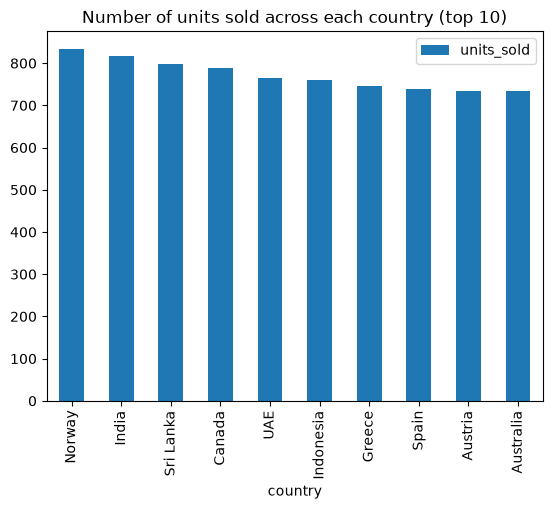

In [21]:
country_units.head(10).plot(
    title = 'Number of units sold across each country (top 10)',
    kind='bar')

## Sales category ranking by units

In [22]:
category_units = df_cleaned.groupby('category', sort=True).agg({'units_sold':'sum'})
category_units = category_units.sort_values(by=['units_sold'], ascending=False)
display(category_units)

,units_sold
category,
Galaxy S,5567
Accessories,4875
Galaxy A,4498
Galaxy Tab,3706
Galaxy Watch,3453
Smart TV,2941
Appliances,2508
Monitor,2486
Galaxy Z,2436


# Make models

In [23]:
df_model = df_cleaned.copy()

In [24]:
df_model = df_model.drop(columns = 'country')
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15500 non-null  int32  
 1   quarter               15500 non-null  int8   
 2   month                 15500 non-null  int32  
 3   region                15500 non-null  str    
 4   category              15500 non-null  str    
 5   color                 15500 non-null  str    
 6   is_5g                 15500 non-null  str    
 7   unit_price_usd        15500 non-null  float64
 8   discount_pct          15500 non-null  int64  
 9   units_sold            15500 non-null  int64  
 10  discounted_price_usd  15500 non-null  float64
 11  revenue_usd           15500 non-null  float64
 12  sales_channel         15500 non-null  str    
 13  payment_method        15500 non-null  str    
 14  customer_segment      15500 non-null  str    
 15  customer_age_group    15500 no

# Statistics Check

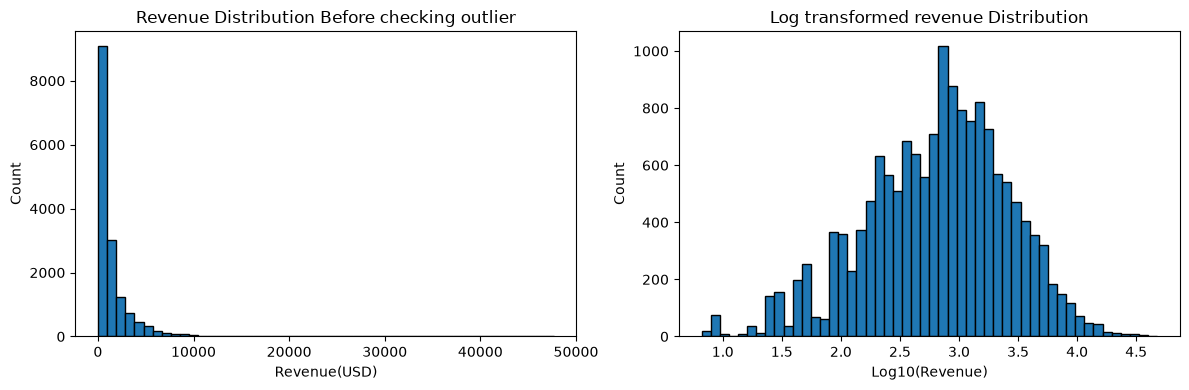

In [25]:
# visualize the revenue distribution

plt.figure(figsize = (12, 4))

plt.subplot(1,2,1)
plt.hist(df_model['revenue_usd'], bins = 50, edgecolor = 'black')
plt.xlabel('Revenue(USD)')
plt.ylabel('Count')
plt.title('Revenue Distribution Before checking outlier')

plt.subplot(1,2,2)
plt.hist(np.log10(df_model['revenue_usd']), bins = 50, edgecolor = 'black')
plt.xlabel('Log10(Revenue)')
plt.ylabel('Count')
plt.title('Log transformed revenue Distribution')

plt.tight_layout()
plt.show()

In [26]:
# check your target variable distributions
print("\nRevenue statistics:")
print(df_model['revenue_usd'].describe())



Revenue statistics:
count    15500.000000
mean      1478.145734
std       2368.688098
min          6.610000
25%        254.265000
50%        739.380000
75%       1695.315000
max      47665.900000
Name: revenue_usd, dtype: float64


In [27]:
# Check for outliers 
print(f"\nrevenue_usd > $30000: {(df_model['revenue_usd'] > 30000).sum()}")
print(f"revenue_usd < $100: {(df_model['revenue_usd'] < 100).sum()}")


revenue_usd > $30000: 12
revenue_usd < $100: 1590


In [28]:
# Check for outliers 
print(f"\nrevenue_usd > $30000: {(df_model['revenue_usd'] > 40000).sum()}")
print(f"revenue_usd < $100: {(df_model['revenue_usd'] < 50).sum()}")


revenue_usd > $30000: 2
revenue_usd < $100: 820


## Display the outliers

In [29]:
print("Top 20 revenue:")
display(df_model.nlargest(20, 'revenue_usd')[['units_sold', 'region', 'category', 'revenue_usd']])

Top 20 revenue:


,units_sold,region,category,revenue_usd
4773,10,Europe,Smart TV,47665.90
4996,10,Europe,Smart TV,43667.00
9800,9,Europe,Smart TV,39789.72
14241,7,Middle East,Smart TV,35950.04
7835,8,Oceania,Smart TV,35862.80
11855,7,Asia,Smart TV,35545.65
10259,7,Europe,Smart TV,34561.10
8839,7,Asia,Smart TV,32532.22
13584,6,Asia,Smart TV,32406.00
6172,6,Asia,Smart TV,31542.00


We can see that most of the revenue is come from bulk purchase of SmartTV

In [30]:
print("Bottom 10 revenue:")
display(df_model.nsmallest(10, 'revenue_usd')[['units_sold', 'region', 'category', 'revenue_usd']])

Bottom 10 revenue:


,units_sold,region,category,revenue_usd
4622,1,Europe,Accessories,6.61
10068,1,Europe,Accessories,6.61
5137,1,Asia,Accessories,6.69
9750,1,Europe,Accessories,6.81
12012,1,Europe,Accessories,7.04
5331,1,Asia,Accessories,7.07
8223,1,Africa,Accessories,7.17
5372,1,Asia,Accessories,7.34
8635,1,Europe,Accessories,7.45
7221,1,Asia,Accessories,7.49


# Change the revenue into log form

In [31]:
df_model['log_revenue'] = np.log10(df_model['revenue_usd'])
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15500 non-null  int32  
 1   quarter               15500 non-null  int8   
 2   month                 15500 non-null  int32  
 3   region                15500 non-null  str    
 4   category              15500 non-null  str    
 5   color                 15500 non-null  str    
 6   is_5g                 15500 non-null  str    
 7   unit_price_usd        15500 non-null  float64
 8   discount_pct          15500 non-null  int64  
 9   units_sold            15500 non-null  int64  
 10  discounted_price_usd  15500 non-null  float64
 11  revenue_usd           15500 non-null  float64
 12  sales_channel         15500 non-null  str    
 13  payment_method        15500 non-null  str    
 14  customer_segment      15500 non-null  str    
 15  customer_age_group    15500 no

In [32]:
df_model = df_model.drop(columns = 'revenue_usd')


In [33]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15500 non-null  int32  
 1   quarter               15500 non-null  int8   
 2   month                 15500 non-null  int32  
 3   region                15500 non-null  str    
 4   category              15500 non-null  str    
 5   color                 15500 non-null  str    
 6   is_5g                 15500 non-null  str    
 7   unit_price_usd        15500 non-null  float64
 8   discount_pct          15500 non-null  int64  
 9   units_sold            15500 non-null  int64  
 10  discounted_price_usd  15500 non-null  float64
 11  sales_channel         15500 non-null  str    
 12  payment_method        15500 non-null  str    
 13  customer_segment      15500 non-null  str    
 14  customer_age_group    15500 non-null  str    
 15  return_status         15500 no

# One hot encoding

### return status

In [34]:
df_model.head()

,year,quarter,month,region,category,color,is_5g,unit_price_usd,discount_pct,units_sold,discounted_price_usd,sales_channel,payment_method,customer_segment,customer_age_group,return_status,log_revenue
0,2021,1,1,South America,Galaxy Tab,Graphite,No,1246.77,0,1,1246.77,E-commerce Platform,Samsung Pay,Business,45–54,Kept,3.095786
1,2021,1,3,South America,Galaxy S,Titanium Violet,Yes,809.84,10,2,728.86,Authorized Reseller,Net Banking,Government,55+,Kept,3.163674
2,2021,2,5,South America,Galaxy A,Awesome Black,Yes,410.19,12,6,360.97,Corporate / B2B,Gift Card,Individual,25–34,Kept,3.335622
3,2021,3,7,South America,Monitor,Black,No,242.69,0,3,242.69,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,Kept,2.862173
4,2021,3,9,South America,Galaxy Z,Cream,Yes,1562.98,0,2,1562.98,Authorized Reseller,Gift Card,Business,55+,Kept,3.494983


In [35]:
df_model = df_model.join(pd.get_dummies(df_model['return_status'],dtype='int32', prefix='return_status')) 
df_model = df_model.drop(columns = 'return_status')


In [36]:
# df_model = df_model.drop(columns = 'color')

In [37]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     15500 non-null  int32  
 1   quarter                  15500 non-null  int8   
 2   month                    15500 non-null  int32  
 3   region                   15500 non-null  str    
 4   category                 15500 non-null  str    
 5   color                    15500 non-null  str    
 6   is_5g                    15500 non-null  str    
 7   unit_price_usd           15500 non-null  float64
 8   discount_pct             15500 non-null  int64  
 9   units_sold               15500 non-null  int64  
 10  discounted_price_usd     15500 non-null  float64
 11  sales_channel            15500 non-null  str    
 12  payment_method           15500 non-null  str    
 13  customer_segment         15500 non-null  str    
 14  customer_age_group       15500 no

### is 5g, color

In [38]:
cols = ['is_5g']

for col in cols: 
    df_model = df_model.join(pd.get_dummies(df_model[col],dtype='int32', prefix=col)) 
    df_model = df_model.drop(columns=col)

In [39]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     15500 non-null  int32  
 1   quarter                  15500 non-null  int8   
 2   month                    15500 non-null  int32  
 3   region                   15500 non-null  str    
 4   category                 15500 non-null  str    
 5   color                    15500 non-null  str    
 6   unit_price_usd           15500 non-null  float64
 7   discount_pct             15500 non-null  int64  
 8   units_sold               15500 non-null  int64  
 9   discounted_price_usd     15500 non-null  float64
 10  sales_channel            15500 non-null  str    
 11  payment_method           15500 non-null  str    
 12  customer_segment         15500 non-null  str    
 13  customer_age_group       15500 non-null  str    
 14  log_revenue              15500 no

## Ordinal method

 Ordinal method
- customer_age_group: 5 unique values
- region: 8 unique values
- category: 11 unique values
- customer_segment: 5 unique values

In [40]:
# Check remaining categorical columns
categorical_cols =['customer_age_group', 
                            'region',
                            'category',
                            'customer_segment',
                            'color',
                            'sales_channel',
                            'payment_method']

for col in categorical_cols:
    n_unique = df_model[col].nunique()   # to see if any one hot encoding opportinities
    print(f"\n{col}: {n_unique} unique values")
    print(df_model[col].value_counts())
   


customer_age_group: 5 unique values
customer_age_group
25–34    3227
55+      3094
35–44    3087
45–54    3055
18–24    3037
Name: count, dtype: int64

region: 8 unique values
region
Europe           5327
Asia             4481
Africa           1512
South America    1470
North America     913
Europe/Asia       607
Oceania           601
Middle East       589
Name: count, dtype: int64

category: 11 unique values
category
Galaxy S        2316
Accessories     2101
Galaxy A        1892
Galaxy Tab      1524
Galaxy Watch    1486
Smart TV        1295
Galaxy Z        1058
Appliances      1052
Monitor         1046
Galaxy Buds      869
Galaxy M         861
Name: count, dtype: int64

customer_segment: 5 unique values
customer_segment
Government    3140
Individual    3134
Business      3097
Enterprise    3075
Education     3054
Name: count, dtype: int64

color: 34 unique values
color
Black               1962
White               1926
Silver              1325
Cream               1094
Graphite        

# Simplify colours 

In [41]:
# Simplify colours 
Achromatic  = ['Black',
'White',
'Silver',
'Graphite',
'Phantom Black',
'Awesome Graphite',
'Awesome White', 
'Awesome Black',
'Phantom White',
'Titanium Black',
'Titanium Gray',
'Prism Black',
'Gray']

Green = ['Lime','Awesome Lime','Green' ]


Blue=[ 
'Blue',
'Navy',
'Icy Blue',
'Sapphire',
'Dark Blue' ,
'Deep Ocean Blue',
'Waterfall Blue' ,
'Midnight Blue']


Pink_violet=[
'Cream',
'Beige',
'Bora Purple',
'Lavender'
'Awesome Peach',
'Awesome Violet',
'Titanium Violet'
]

Other_colour =[
'Gold',
'Titanium Yellow', 
'Graph' 
]

df_model['color'] = df_model['color'].replace(to_replace=Achromatic, value="Black")
df_model['color'] = df_model['color'].replace(to_replace=Green, value="Green")
df_model['color'] = df_model['color'].replace(to_replace=Blue, value="Blue")
df_model['color'] = df_model['color'].replace(to_replace=Pink_violet, value="Pink_violet")
df_model['color'] = df_model['color'].replace(to_replace=Other_colour, value="Other_col")

In [42]:
df_model['color']

0              Black
1        Pink_violet
2              Black
3              Black
4        Pink_violet
            ...     
15495    Pink_violet
15496          Black
15497    Pink_violet
15498          Black
15499          Black
Name: color, Length: 15500, dtype: str

In [43]:
df_model

,year,quarter,month,region,category,color,unit_price_usd,discount_pct,units_sold,discounted_price_usd,sales_channel,payment_method,customer_segment,customer_age_group,log_revenue,return_status_Exchanged,return_status_Kept,return_status_Returned,is_5g_No,is_5g_Yes
0,2021,1,1,South America,Galaxy Tab,Black,1246.77,0,1,1246.77,E-commerce Platform,Samsung Pay,Business,45–54,3.095786,0,1,0,1,0
1,2021,1,3,South America,Galaxy S,Pink_violet,809.84,10,2,728.86,Authorized Reseller,Net Banking,Government,55+,3.163674,0,1,0,0,1
2,2021,2,5,South America,Galaxy A,Black,410.19,12,6,360.97,Corporate / B2B,Gift Card,Individual,25–34,3.335622,0,1,0,0,1
3,2021,3,7,South America,Monitor,Black,242.69,0,3,242.69,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,2.862173,0,1,0,1,0
4,2021,3,9,South America,Galaxy Z,Pink_violet,1562.98,0,2,1562.98,Authorized Reseller,Gift Card,Business,55+,3.494983,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15495,2024,3,8,Asia,Galaxy A,Pink_violet,476.87,0,1,476.87,Samsung Store,BNPL (Buy Now Pay Later),Government,25–34,2.678400,0,1,0,0,1
15496,2024,3,8,Asia,Smart TV,Black,4790.45,0,3,4790.45,Carrier Store,EMI / Installment,Government,55+,4.157498,0,0,1,1,0
15497,2024,3,9,Asia,Galaxy Watch,Pink_violet,295.02,5,2,280.27,Online (Samsung.com),Credit Card,Enterprise,45–54,2.748607,0,1,0,1,0
15498,2024,3,9,Asia,Appliances,Black,191.25,15,1,162.56,Third-Party Retailer,Debit Card,Business,18–24,2.211014,0,1,0,1,0


In [44]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     15500 non-null  int32  
 1   quarter                  15500 non-null  int8   
 2   month                    15500 non-null  int32  
 3   region                   15500 non-null  str    
 4   category                 15500 non-null  str    
 5   color                    15500 non-null  str    
 6   unit_price_usd           15500 non-null  float64
 7   discount_pct             15500 non-null  int64  
 8   units_sold               15500 non-null  int64  
 9   discounted_price_usd     15500 non-null  float64
 10  sales_channel            15500 non-null  str    
 11  payment_method           15500 non-null  str    
 12  customer_segment         15500 non-null  str    
 13  customer_age_group       15500 non-null  str    
 14  log_revenue              15500 no

# One hot encoding for rest of caegories

customer_age_group: 5 unique values
region: 8 unique values
category: 11 unique values
customer_segment: 5 unique values
color : 7 unique values
sales_channel: 7 unique values

In [45]:
# customer age group
df_model = df_model.join(pd.get_dummies(df_model['customer_age_group'],dtype='int32', prefix='customer_age_group')) 
df_model = df_model.drop(columns = 'customer_age_group')

In [46]:
# region
df_model = df_model.join(pd.get_dummies(df_model['region'],dtype='int32', prefix='region')) 
df_model = df_model.drop(columns = 'region')

In [47]:
# category
df_model = df_model.join(pd.get_dummies(df_model['category'],dtype='int32', prefix='category')) 
df_model = df_model.drop(columns = 'category')

In [48]:
# customer_segment
df_model = df_model.join(pd.get_dummies(df_model['customer_segment'],dtype='int32', prefix='customer_segment')) 
df_model = df_model.drop(columns = 'customer_segment')

In [49]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         15500 non-null  int32  
 1   quarter                      15500 non-null  int8   
 2   month                        15500 non-null  int32  
 3   color                        15500 non-null  str    
 4   unit_price_usd               15500 non-null  float64
 5   discount_pct                 15500 non-null  int64  
 6   units_sold                   15500 non-null  int64  
 7   discounted_price_usd         15500 non-null  float64
 8   sales_channel                15500 non-null  str    
 9   payment_method               15500 non-null  str    
 10  log_revenue                  15500 non-null  float64
 11  return_status_Exchanged      15500 non-null  int32  
 12  return_status_Kept           15500 non-null  int32  
 13  return_status_Returned     

In [50]:
#  color
df_model = df_model.join(pd.get_dummies(df_model['color'],dtype='int32', prefix='color')) 
df_model = df_model.drop(columns = 'color')

In [51]:
#  sales_channel
df_model = df_model.join(pd.get_dummies(df_model['sales_channel'],dtype='int32', prefix='sales_channel')) 
df_model = df_model.drop(columns = 'sales_channel')

In [52]:
# payment_method
df_model = df_model.join(pd.get_dummies(df_model['payment_method'],dtype='int32', prefix='payment_method')) 
df_model = df_model.drop(columns = 'payment_method')

In [53]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 64 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   year                                     15500 non-null  int32  
 1   quarter                                  15500 non-null  int8   
 2   month                                    15500 non-null  int32  
 3   unit_price_usd                           15500 non-null  float64
 4   discount_pct                             15500 non-null  int64  
 5   units_sold                               15500 non-null  int64  
 6   discounted_price_usd                     15500 non-null  float64
 7   log_revenue                              15500 non-null  float64
 8   return_status_Exchanged                  15500 non-null  int32  
 9   return_status_Kept                       15500 non-null  int32  
 10  return_status_Returned                   15500 non-null  

# Model Training & Feature Importance

## Separate target and features

In [54]:
# Separate features and target
X = df_model.drop(columns=['log_revenue'])
y = df_model['log_revenue']

print(f"Features shape : {X.shape}")
print(f"Target shape: {y.shape}")

Features shape : (15500, 63)
Target shape: (15500,)


## Check first correlation and multicolinarety 

In [55]:
# Calculate correlation with target 
correlations = X.corrwith(y).sort_values(ascending=False)

print("\n Top correlations of features with log_revenue: ")
print(correlations.head(20))


 Top correlations of features with log_revenue: 
discounted_price_usd                  0.678524
unit_price_usd                        0.677464
units_sold                            0.448927
category_Smart TV                     0.304042
category_Galaxy S                     0.263553
is_5g_Yes                             0.234661
category_Galaxy Z                     0.210245
category_Appliances                   0.142310
category_Monitor                      0.135137
category_Galaxy Tab                   0.122116
color_Lavender                        0.109571
color_Pink_violet                     0.086889
color_Other_col                       0.071831
color_Green                           0.069833
color_Black                           0.042324
region_North America                  0.014257
payment_method_Net Banking            0.011278
sales_channel_Online (Samsung.com)    0.010756
payment_method_Samsung Pay            0.007582
customer_segment_Individual           0.006567
dtype: flo

In [56]:
print(correlations.tail(20))

customer_age_group_45–54                  -0.006422
sales_channel_Authorized Reseller         -0.006513
quarter                                   -0.006595
month                                     -0.006633
return_status_Exchanged                   -0.007430
payment_method_BNPL (Buy Now Pay Later)   -0.008322
sales_channel_E-commerce Platform         -0.009430
customer_segment_Education                -0.009728
region_Asia                               -0.009781
region_Oceania                            -0.010191
payment_method_Debit Card                 -0.013296
color_Awesome Peach                       -0.048448
discount_pct                              -0.052327
category_Galaxy Watch                     -0.076360
category_Galaxy M                         -0.110894
category_Galaxy A                         -0.111516
category_Galaxy Buds                      -0.163439
is_5g_No                                  -0.234661
color_Blue                                -0.289134
category_Acc

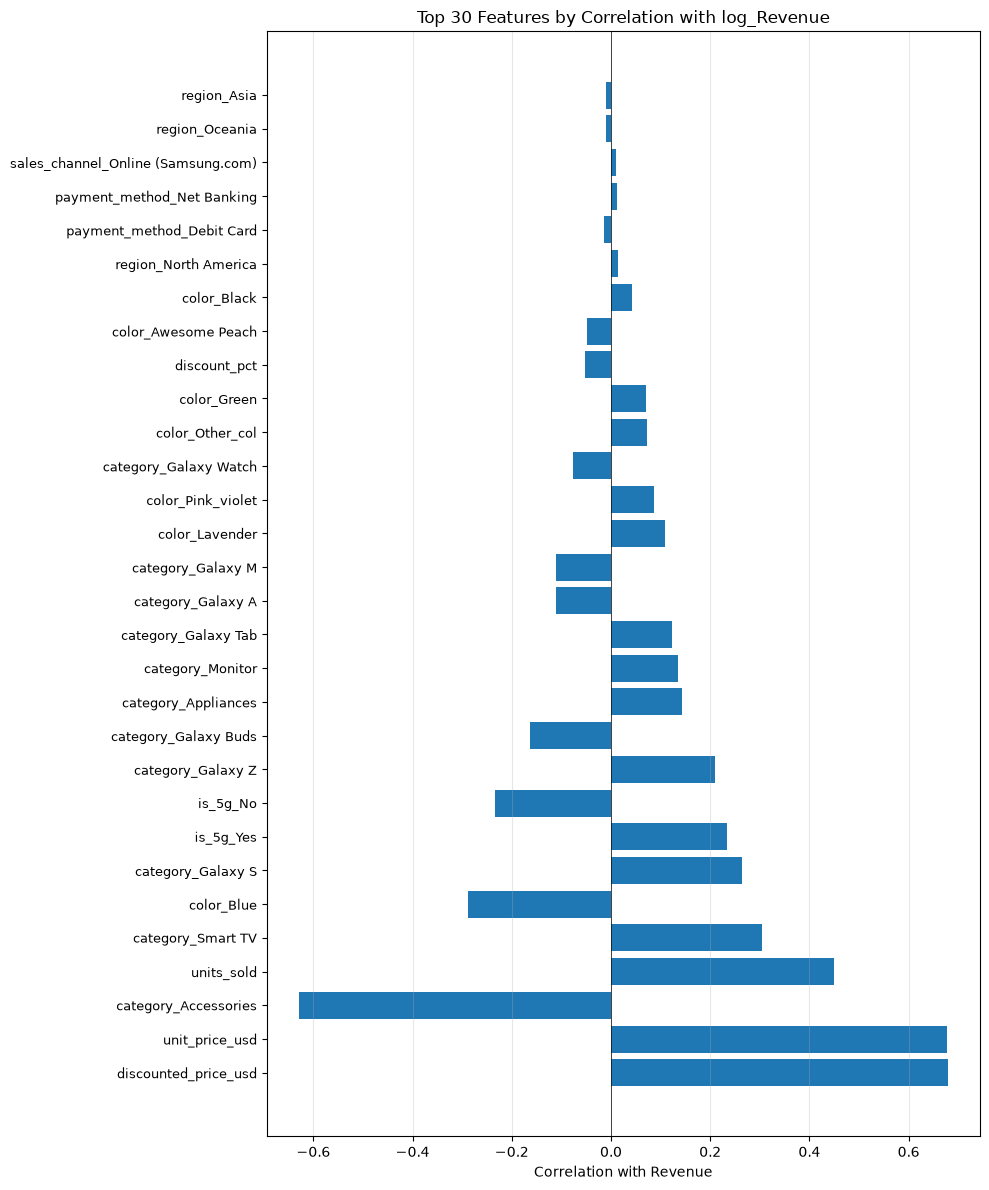

In [57]:
# Visualize top correlations 
plt.figure(figsize = (10,12))

# Get top 30 features by absolute correlation
top_features = correlations.abs().sort_values(ascending=False).head(30)
top_correlations = correlations[top_features.index]

plt.barh(range(len(top_correlations)), top_correlations.values)
plt.yticks(range(len(top_correlations)), top_correlations.index, fontsize=9)
plt.xlabel('Correlation with Revenue')
plt.title('Top 30 Features by Correlation with log_Revenue')
plt.axvline(x=0, color = 'black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Check the heatmap and collinearity

In [58]:
# look at heatmaps

# Check for multicollinearity among top features
print("\n Checking for Multicollinearity ")

top_20_features = correlations.abs().sort_values(ascending=False).head(20).index.tolist()

# Correlation matrix of top features
feature_corr = X[top_20_features].corr()

# Finding highly correlated feature pairs (>0.7)
high_corr_pairs = []
for i in range(len(feature_corr.columns)): 
    for j in range(i + 1, len(feature_corr.columns)): 
        if abs(feature_corr.iloc[i,j]) > 0.7:
            high_corr_pairs.append((feature_corr.columns[i], feature_corr.columns[j], feature_corr.iloc[i,j]))

if high_corr_pairs:
    print("\nHighly correlated feature pairs (>0.7):")
    for feat1, feat2, corr in high_corr_pairs: 
        print(f"    {feat1} <-> {feat2}: {corr:.3f}")

else: 
    print("\nNo highly correlated feature pairs found (threshold: 0.7)")





 Checking for Multicollinearity 

Highly correlated feature pairs (>0.7):
    discounted_price_usd <-> unit_price_usd: 0.996
    is_5g_Yes <-> is_5g_No: -1.000


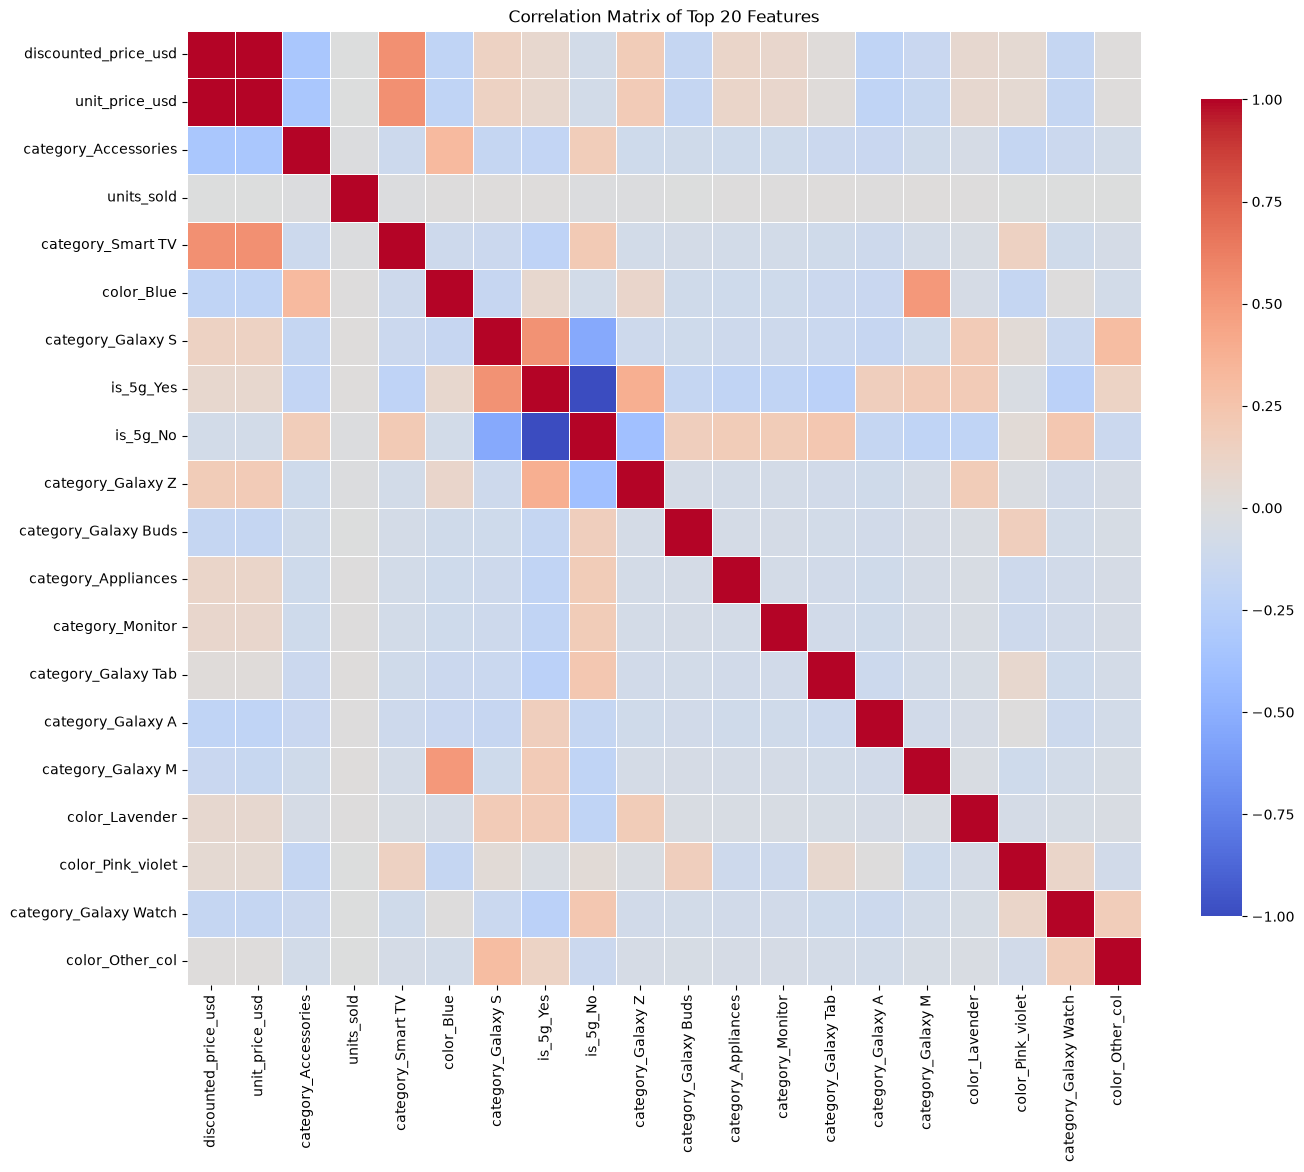

In [59]:
# Heatmap of top features: 
plt.figure(figsize=(14,12))
sns.heatmap(feature_corr, annot=False, cmap='coolwarm', center=0,
            square=True, linewidth=0.5, cbar_kws={"shrink":0.8})
plt.title('Correlation Matrix of Top 20 Features')
plt.tight_layout()
plt.show()

### Drop highly multicollinear features

In [60]:
multicollinear_drops = ['unit_price_usd','is_5g_No']

X_reduced = X.drop(columns =multicollinear_drops)
print(f"Shape after dropping multicollinear features: {X_reduced.shape}")

Shape after dropping multicollinear features: (15500, 61)


In [61]:
# ReCalculate correlation with target 
correlations_reduced = X_reduced.corrwith(y).sort_values(ascending=False)

print("\nTOP 20 POSITIVE (After removing multicollinearity)")
print(correlations_reduced.head(20))


TOP 20 POSITIVE (After removing multicollinearity)
discounted_price_usd                  0.678524
units_sold                            0.448927
category_Smart TV                     0.304042
category_Galaxy S                     0.263553
is_5g_Yes                             0.234661
category_Galaxy Z                     0.210245
category_Appliances                   0.142310
category_Monitor                      0.135137
category_Galaxy Tab                   0.122116
color_Lavender                        0.109571
color_Pink_violet                     0.086889
color_Other_col                       0.071831
color_Green                           0.069833
color_Black                           0.042324
region_North America                  0.014257
payment_method_Net Banking            0.011278
sales_channel_Online (Samsung.com)    0.010756
payment_method_Samsung Pay            0.007582
customer_segment_Individual           0.006567
region_Europe                         0.006246
dtype: f

In [62]:
# Now drop very weak predictors (|correlation| < 0.01 )
weak_features = correlations_reduced[abs(correlations_reduced) < 0.01].index.tolist()
print(f"\n Features with correlations < 0.01: {len(weak_features)} ")
print(weak_features[:20]) # show first 20 


 Features with correlations < 0.01: 34 
['payment_method_Samsung Pay', 'customer_segment_Individual', 'region_Europe', 'customer_age_group_35–44', 'region_Europe/Asia', 'customer_age_group_25–34', 'customer_segment_Enterprise', 'sales_channel_Corporate / B2B', 'return_status_Kept', 'sales_channel_Third-Party Retailer', 'region_Middle East', 'sales_channel_Samsung Store', 'payment_method_Cash', 'year', 'customer_age_group_18–24', 'region_South America', 'payment_method_Credit Card', 'return_status_Returned', 'customer_segment_Government', 'payment_method_Gift Card']


In [63]:
# Drop weak features

X_final = X_reduced.drop(columns=weak_features)

print(f"\n===Final Feature Set===")
print(f"Features: {X_final.shape[1]}")
print(f"Rows: {X_final.shape[0]}")


===Final Feature Set===
Features: 27
Rows: 15500


In [64]:
# Show final feature list

final_correlations = X_final.corrwith(y).sort_values(ascending=False)
print("\nFinal features ranked by correlation: ")
print(final_correlations)


Final features ranked by correlation: 
discounted_price_usd                  0.678524
units_sold                            0.448927
category_Smart TV                     0.304042
category_Galaxy S                     0.263553
is_5g_Yes                             0.234661
category_Galaxy Z                     0.210245
category_Appliances                   0.142310
category_Monitor                      0.135137
category_Galaxy Tab                   0.122116
color_Lavender                        0.109571
color_Pink_violet                     0.086889
color_Other_col                       0.071831
color_Green                           0.069833
color_Black                           0.042324
region_North America                  0.014257
payment_method_Net Banking            0.011278
sales_channel_Online (Samsung.com)    0.010756
region_Oceania                       -0.010191
payment_method_Debit Card            -0.013296
color_Awesome Peach                  -0.048448
discount_pct        

In [65]:
df_final=pd.concat([X_final, y], axis=1)
df_final.head()

,discount_pct,units_sold,discounted_price_usd,is_5g_Yes,region_North America,region_Oceania,category_Accessories,category_Appliances,category_Galaxy A,category_Galaxy Buds,...,color_Black,color_Blue,color_Green,color_Lavender,color_Other_col,color_Pink_violet,sales_channel_Online (Samsung.com),payment_method_Debit Card,payment_method_Net Banking,log_revenue
0,0,1,1246.77,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,3.095786
1,10,2,728.86,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,3.163674
2,12,6,360.97,1,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,3.335622
3,0,3,242.69,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,2.862173
4,0,2,1562.98,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,3.494983


# Build ML OOP

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [67]:
# define Model calss
class Model:

    def __init__(self, data = df_final, model_type = None): # default = None 
        # self.model_coef = model_coef
        self.df = data
        self.modeltype = model_type

        
        
        if model_type == 'random_forest_regression':
            # self.random_forest = RandomForestRegressor() # we can also define another RF model object in Model
            self.user_defined_model = RandomForestRegressor()
        # if another model
        elif model_type == 'random_forest_classifier':
            self.user_defined_model = RandomForestClassifier()

        elif model_type == 'linear_regression':
            self.user_defined_model = LinearRegression()

        else: 
            print("no ML model selected")
            exit()
        

    # split the data into train test 
    def split(self, test_size):
        X = self.df.drop(columns=['log_revenue'])
        y = self.df['log_revenue']
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, y, 
                                                                                test_size = test_size, 
                                                                                random_state = 42)
        print(f"Training set:{self.X_train.shape}")
        print(f"Test set: {self.X_test.shape}")

        return self.X_train, self.X_test, self.y_train, self.y_test
        
    # define a fit function 
    def fit(self):
        self.model = self.user_defined_model.fit(self.X_train, self.y_train)
        
        if self.modeltype ==  'linear_regression':
            self.model_coef = self.model.coef_
            return self.model_coef
        
        elif self.modeltype ==  'random_forest_regression':
            self.model_coef = self.user_defined_model.feature_importances_
            return self.model_coef

        else:
            return "No return type"
    
    # define a predict function
    def predict(self):
        self.y_pred_train = self.user_defined_model.predict(self.X_train) 
        self.y_pred_test = self.user_defined_model.predict(self.X_test) 

        return self.y_pred_train,self.y_pred_test 


    def evaluation(self):
        print("Model performance:")
        print("\nTraining set:" )
        print(f"R2 score: {r2_score(self.y_train, self.y_pred_train):.4f}")
        print(f"MAE: ${mean_absolute_error(self.y_train, self.y_pred_train):,.2f}")

        print("\nTest set:" )
        print(f"R2 score: {r2_score(self.y_test, self.y_pred_test):.4f}")
        print(f"MAE: ${mean_absolute_error(self.y_test, self.y_pred_test):,.2f}")




In [68]:

# model_instance = Model(model_type = 'rf')
model_instance = Model( model_type = 'linear_regression')

X_train, X_test, y_train, y_test = model_instance.split(0.2)

# print test predictions 
coeff = model_instance.fit()

# print(model_instance.predict())
y_pred_train,y_pred_test = model_instance.predict()

model_instance.evaluation()

print ('\nAccuracy: ', model_instance.model.score(model_instance.X_test, model_instance.y_test))

Training set:(12400, 27)
Test set: (3100, 27)
Model performance:

Training set:
R2 score: 0.9088
MAE: $0.14

Test set:
R2 score: 0.9020
MAE: $0.14

Accuracy:  0.9020100073990232


**The model score increse significantly after log transforming revenue**

In [69]:
y_pred_train

array([2.96876428, 3.2888524 , 3.18256845, ..., 2.41319209, 2.08192634,
       1.76983178], shape=(12400,))

In [70]:
coeff

array([-2.33028750e-03,  1.41722218e-01,  3.26817176e-04,  2.36500219e-01,
        6.69721283e-03, -3.88405452e-03, -7.37262996e-01,  2.72594929e-01,
       -1.41940411e-01, -1.93492194e-01, -2.64250824e-01,  1.26653375e-01,
        2.47097910e-01,  2.96541757e-02,  1.23760343e-01,  2.72673954e-01,
        2.64511739e-01, -8.39023390e-04, -3.04222498e-03, -1.15732428e-02,
        7.72622906e-03,  9.93185564e-03,  2.49458406e-03, -4.69817760e-03,
        4.88509976e-03,  2.61868082e-03, -5.22065611e-04])

In [71]:
X_final.columns

Index(['discount_pct', 'units_sold', 'discounted_price_usd', 'is_5g_Yes',
       'region_North America', 'region_Oceania', 'category_Accessories',
       'category_Appliances', 'category_Galaxy A', 'category_Galaxy Buds',
       'category_Galaxy M', 'category_Galaxy S', 'category_Galaxy Tab',
       'category_Galaxy Watch', 'category_Galaxy Z', 'category_Monitor',
       'category_Smart TV', 'color_Awesome Peach', 'color_Black', 'color_Blue',
       'color_Green', 'color_Lavender', 'color_Other_col', 'color_Pink_violet',
       'sales_channel_Online (Samsung.com)', 'payment_method_Debit Card',
       'payment_method_Net Banking'],
      dtype='str')

In [72]:
# Top 10 most important features (by coefficient magnitude)

coefficients = pd.DataFrame({
    'Feature':X_final.columns,
    'Coefficient':coeff
})

coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
top_features = coefficients.nlargest(10, 'Abs_Coefficient')

print("\n TOP 10 MOST IMPORTANT FEATURES ")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))


 TOP 10 MOST IMPORTANT FEATURES 
             Feature  Coefficient
category_Accessories    -0.737263
    category_Monitor     0.272674
 category_Appliances     0.272595
   category_Smart TV     0.264512
   category_Galaxy M    -0.264251
 category_Galaxy Tab     0.247098
           is_5g_Yes     0.236500
category_Galaxy Buds    -0.193492
   category_Galaxy A    -0.141940
          units_sold     0.141722


## Plot the results

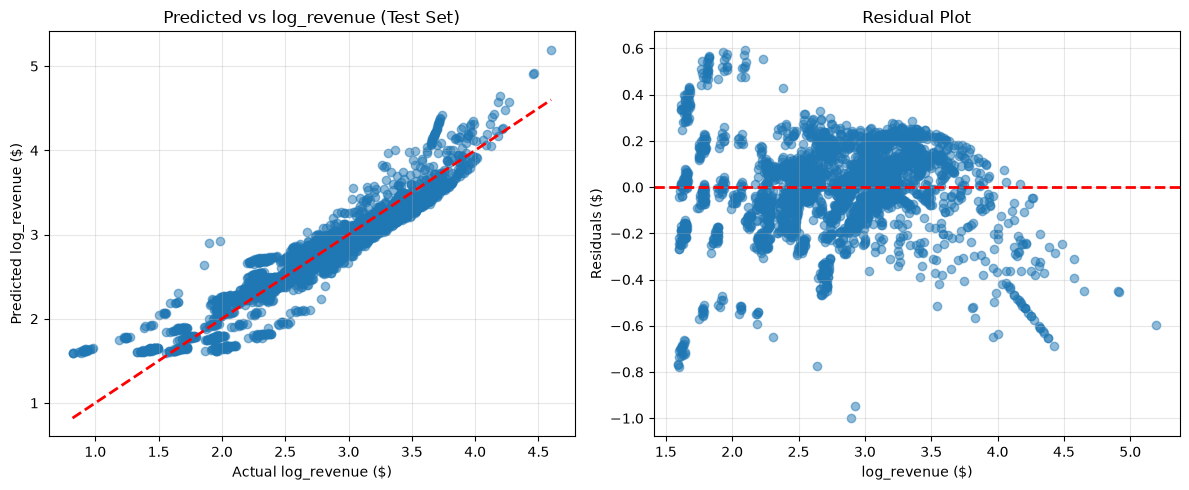

In [73]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual log_revenue ($)')
plt.ylabel('Predicted log_revenue ($)')
plt.title('Predicted vs log_revenue (Test Set)')
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('log_revenue ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Show significant coefficients

In [74]:
coefficients_sorted = coefficients.sort_values('Coefficient', ascending=False)

print("\n TOP 10 Positive coefficeints (Increase Revenue) ")
print(coefficients_sorted.head(10)[['Feature', 'Coefficient']].to_string(index=False))


 TOP 10 Positive coefficeints (Increase Revenue) 
              Feature  Coefficient
     category_Monitor     0.272674
  category_Appliances     0.272595
    category_Smart TV     0.264512
  category_Galaxy Tab     0.247098
            is_5g_Yes     0.236500
           units_sold     0.141722
    category_Galaxy S     0.126653
    category_Galaxy Z     0.123760
category_Galaxy Watch     0.029654
       color_Lavender     0.009932


In [75]:
coefficients_sorted = coefficients.sort_values('Coefficient', ascending=False)

print("\n TOP 10 Negative coefficeints (Not help Revenue) ")
print(coefficients_sorted.tail(10)[['Feature', 'Coefficient']].to_string(index=False))


 TOP 10 Negative coefficeints (Not help Revenue) 
             Feature  Coefficient
 color_Awesome Peach    -0.000839
        discount_pct    -0.002330
         color_Black    -0.003042
      region_Oceania    -0.003884
   color_Pink_violet    -0.004698
          color_Blue    -0.011573
   category_Galaxy A    -0.141940
category_Galaxy Buds    -0.193492
   category_Galaxy M    -0.264251
category_Accessories    -0.737263


# Try other ML models

## Random forest regression

In [76]:
# model_instance = Model(model_type = 'rf')
model_instance = Model( model_type = 'random_forest_regression')

X_train, X_test, y_train, y_test = model_instance.split(0.2)

# print test predictions 
feature_importance = model_instance.fit()

# print(model_instance.predict())
y_pred_train,y_pred_test = model_instance.predict()

model_instance.evaluation()

print ('\nAccuracy: ', model_instance.model.score(model_instance.X_test, model_instance.y_test))

Training set:(12400, 27)
Test set: (3100, 27)
Model performance:

Training set:
R2 score: 1.0000
MAE: $0.00

Test set:
R2 score: 1.0000
MAE: $0.00

Accuracy:  0.9999581585238441


In [77]:
feature_importance

array([3.89027654e-05, 2.21516865e-01, 7.78399120e-01, 2.74917403e-06,
       1.96932638e-06, 1.61561777e-06, 7.92300140e-06, 6.91365630e-07,
       8.00192666e-07, 1.35274143e-06, 1.68451460e-06, 4.38301339e-07,
       8.06662263e-07, 6.60657401e-07, 4.21370489e-07, 6.48090635e-07,
       4.66304308e-06, 3.37885899e-07, 4.03736892e-06, 2.86639471e-06,
       9.50316820e-07, 1.16226892e-07, 3.02744237e-07, 1.49654270e-06,
       3.08721208e-06, 3.71337851e-06, 1.77949970e-06])

In [78]:
# Top 10 most important features (by coefficient magnitude)

feat_importance = pd.DataFrame({
    'Feature':X_final.columns,
    'Importance':feature_importance
})

feat_importance['Abs_importance'] = abs(feat_importance['Importance'])
top_features = feat_importance.nlargest(10, 'Abs_importance')

print("\n TOP 10 MOST IMPORTANT FEATURES ")
print(top_features[['Feature', 'Importance']].to_string(index=False))


 TOP 10 MOST IMPORTANT FEATURES 
                           Feature  Importance
              discounted_price_usd    0.778399
                        units_sold    0.221517
                      discount_pct    0.000039
              category_Accessories    0.000008
                 category_Smart TV    0.000005
                       color_Black    0.000004
         payment_method_Debit Card    0.000004
sales_channel_Online (Samsung.com)    0.000003
                        color_Blue    0.000003
                         is_5g_Yes    0.000003


## Try another RF regression

In [79]:
df_backup = df_final.copy()
df_final = df_final.drop(columns = 'discounted_price_usd')

In [80]:
# Need to run again the OOP here for new dataset

# define Model calss
class Model:

    def __init__(self, data = df_final, model_type = None): # default = None 
        # self.model_coef = model_coef
        self.df = data
        self.modeltype = model_type

        
        
        if model_type == 'random_forest_regression':
            # self.random_forest = RandomForestRegressor() # we can also define another RF model object in Model
            self.user_defined_model = RandomForestRegressor()
        # if another model
        elif model_type == 'random_forest_classifier':
            self.user_defined_model = RandomForestClassifier()

        elif model_type == 'linear_regression':
            self.user_defined_model = LinearRegression()

        else: 
            print("no ML model selected")
            exit()
        

    # split the data into train test 
    def split(self, test_size):
        X = self.df.drop(columns=['log_revenue'])
        y = self.df['log_revenue']
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, y, 
                                                                                test_size = test_size, 
                                                                                random_state = 42)
        print(f"Training set:{self.X_train.shape}")
        print(f"Test set: {self.X_test.shape}")

        return self.X_train, self.X_test, self.y_train, self.y_test
        
    # define a fit function 
    def fit(self):
        self.model = self.user_defined_model.fit(self.X_train, self.y_train)
        
        if self.modeltype ==  'linear_regression':
            self.model_coef = self.model.coef_
            return self.model_coef
        
        elif self.modeltype ==  'random_forest_regression':
            self.model_coef = self.user_defined_model.feature_importances_
            return self.model_coef

        else:
            return "No return type"
    
    # define a predict function
    def predict(self):
        self.y_pred_train = self.user_defined_model.predict(self.X_train) 
        self.y_pred_test = self.user_defined_model.predict(self.X_test) 

        return self.y_pred_train,self.y_pred_test 


    def evaluation(self):
        print("Model performance:")
        print("\nTraining set:" )
        print(f"R2 score: {r2_score(self.y_train, self.y_pred_train):.4f}")
        print(f"MAE: ${mean_absolute_error(self.y_train, self.y_pred_train):,.2f}")

        print("\nTest set:" )
        print(f"R2 score: {r2_score(self.y_test, self.y_pred_test):.4f}")
        print(f"MAE: ${mean_absolute_error(self.y_test, self.y_pred_test):,.2f}")




In [81]:
# Drop the "discounted_price_usd"




# model_instance = Model(model_type = 'rf')
model_instance = Model( model_type = 'random_forest_regression')

X_train, X_test, y_train, y_test = model_instance.split(0.2)

# print test predictions 
feature_importance = model_instance.fit()

# print(model_instance.predict())
y_pred_train,y_pred_test = model_instance.predict()

model_instance.evaluation()

print ('\nAccuracy: ', model_instance.model.score(model_instance.X_test, model_instance.y_test))

Training set:(12400, 26)
Test set: (3100, 26)
Model performance:

Training set:
R2 score: 0.9141
MAE: $0.12

Test set:
R2 score: 0.8405
MAE: $0.18

Accuracy:  0.8405175561632818


In [82]:
feat_importance = pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':feature_importance
})

feat_importance['Abs_importance'] = abs(feat_importance['Importance'])
top_features = feat_importance.nlargest(10, 'Abs_importance')

print("\n TOP 10 MOST IMPORTANT FEATURES ")
print(top_features[['Feature', 'Importance']].to_string(index=False))


 TOP 10 MOST IMPORTANT FEATURES 
              Feature  Importance
 category_Accessories    0.419268
           units_sold    0.252561
    category_Smart TV    0.056917
category_Galaxy Watch    0.044540
 category_Galaxy Buds    0.041421
    category_Galaxy M    0.039713
    category_Galaxy A    0.037819
         discount_pct    0.023971
            is_5g_Yes    0.022984
    category_Galaxy S    0.007063


In [83]:
top_features

,Feature,Importance,Abs_importance
5,category_Accessories,0.419268,0.419268
1,units_sold,0.252561,0.252561
15,category_Smart TV,0.056917,0.056917
12,category_Galaxy Watch,0.044540,0.044540
8,category_Galaxy Buds,0.041421,0.041421
9,category_Galaxy M,0.039713,0.039713
7,category_Galaxy A,0.037819,0.037819
0,discount_pct,0.023971,0.023971
2,is_5g_Yes,0.022984,0.022984
10,category_Galaxy S,0.007063,0.007063


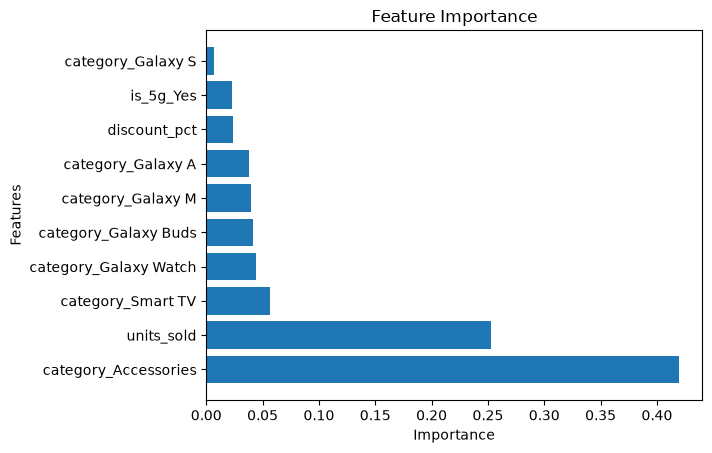

In [84]:
import matplotlib.pyplot as plt
import numpy as np


plt.barh(top_features['Feature'], top_features['Importance'])

plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()